# 09 -- Линейная модель, бустинг, ранжирование и MLP

Все модели получают один пул и одинаковый train/dev. Так отделяю качество отбора от качества генерации.
В baseline уже есть нейросетевой E5. Здесь проверяю небольшую MLP над признаками и отдельную ranking loss.
LSTM не добавляю: истории действий по времени нет, а для коротких текстов уже использую предобученный encoder.
Новые эксперименты идут после открытия исходного holdout. Для выбора использую только dev;
новой независимой оценки по прежнему test не заявляю.

In [1]:
from pathlib import Path
import sys
import json
import time
import random

import joblib
import numpy as np
import pandas as pd
import torch
from torch import nn
from catboost import CatBoostClassifier, CatBoostRanker, Pool
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from IPython.display import display

mo_root = Path.cwd() if (Path.cwd() / 'notebooks').exists() else Path.cwd().parent
get_ipython().run_line_magic('run', str(mo_root / 'notebooks/common.ipynb'))
mo_out = mo_root / 'outputs'
mo_seed = 143
random.seed(mo_seed)
np.random.seed(mo_seed)
torch.manual_seed(mo_seed)
torch.set_num_threads(4)
torch.use_deterministic_algorithms(True)


## 1. Обучающие кандидаты

Группы без найденного позитива исключаю только из обучения. На dev они остаются в знаменателе.
Для классификаторов суммарный вес положительной и неразмеченной части каждого запроса одинаковый.
Каталожные ID и target не попадают в матрицу. Масштабирование обучаю только на rank_train.

In [2]:
mo_train = (
    pd.read_parquet(mo_out / 'cache/extended_rank_train.parquet')
    .sort_values(['query_id', 'pos'])
    .reset_index(drop=True)
)
mo_dev = (
    pd.read_parquet(mo_out / 'cache/extended_dev.parquet')
    .sort_values(['query_id', 'pos'])
    .reset_index(drop=True)
)
mo_queries = pd.read_parquet(mo_out / 'cache/eval_queries.parquet')
mo_dev_queries = mo_queries[mo_queries.split.eq('dev')]
mo_items = pd.read_parquet(mo_out / 'cache/items.parquet', columns=['item_id'])
mo_truth = json.loads((mo_out / 'cache/truth.json').read_text())
mo_dev_truth = {q: mo_truth[q] for q in mo_dev_queries.query_id}
mo_ids = mo_items.item_id.to_numpy()
mo_columns = feature_columns(mo_train)
mo_train['target'] = [
    int(mo_ids[p] in mo_truth[q]) for q, p in zip(mo_train.query_id, mo_train.pos)
]
mo_found = mo_train.groupby('query_id').target.transform('sum')
mo_train = mo_train[mo_found.gt(0)].reset_index(drop=True)
mo_npos = mo_train.groupby('query_id').target.transform('sum')
mo_n = mo_train.groupby('query_id').target.transform('size')
mo_weights = np.where(
    mo_train.target.eq(1), 0.5 / mo_npos, 0.5 / (mo_n - mo_npos).clip(lower=1)
)
mo_weights /= mo_weights.mean()
mo_x = model_matrix(mo_train, mo_columns)
mo_xdev = model_matrix(mo_dev, mo_columns)
mo_share = json.loads((mo_out / 'models/hybrid.json').read_text())['warm_share']
mo_results = []
mo_scores = mo_dev[['query_id', 'pos']].copy()
write_json(
    {'features': mo_columns, 'seed': mo_seed}, mo_out / 'models/extended_features.json'
)


In [3]:
def mo_evaluate(name, scores, seconds):
    predictions = predictions_from_frame(
        mo_dev.assign(score=scores), mo_items, score='score', k=100
    )
    per_query = recall_table(predictions, mo_dev_truth).merge(
        mo_dev_queries[['query_id', 'regime']], on='query_id'
    )
    values = per_query.groupby('regime')['recall@50'].mean()
    mo_scores[name] = scores
    mo_results.append(
        {
            'model': name,
            'cold': values['cold'],
            'warm': values['warm'],
            'objective': (1 - mo_share) * values['cold'] + mo_share * values['warm'],
            'fit_seconds': seconds,
        }
    )
    pd.DataFrame(mo_results).to_csv(
        mo_out / 'validation/model_family_experiments.csv', index=False
    )
    per_query.to_parquet(mo_out / f'validation/dev_{name}.parquet', index=False)
    print(mo_results[-1], flush=True)


## 2. Контроль: исходные 80 признаков

Проверяю, что новая загрузка данных воспроизводит старый dev score. Здесь используется исходная
модель, обученная только на rank_train, а не финальная модель после refit.

In [4]:
mo_original_columns = json.loads((mo_out / 'models/fusion_features.json').read_text())[
    'features'
]
mo_original = CatBoostClassifier().load_model(str(mo_out / 'models/fusion.cbm'))
mo_evaluate(
    'original_300',
    mo_original.predict_proba(model_matrix(mo_dev, mo_original_columns), ntree_end=300)[
        :, 1
    ],
    0.0,
)
assert abs(mo_results[-1]['objective'] - 0.8039733842150236) < 1e-10


{'model': 'original_300', 'cold': np.float64(0.8006388888888889), 'warm': np.float64(0.8095357142857144), 'objective': np.float64(0.8039733842150236), 'fit_seconds': 0.0}


## 3. Линейная модель

Проверяю, достаточно ли линейно сложить сигналы. SGD позволяет обучить логистическую модель
на всем пуле без большой матрицы вторых производных. Использую те же веса запросов.

In [5]:
mo_scaler = StandardScaler().fit(mo_x)
mo_z = np.clip(mo_scaler.transform(mo_x), -10, 10).astype('float32')
mo_zdev = np.clip(mo_scaler.transform(mo_xdev), -10, 10).astype('float32')
mo_start = time.perf_counter()
mo_linear = SGDClassifier(
    loss='log_loss', alpha=0.001, max_iter=20, tol=1e-4, random_state=mo_seed
)
mo_linear.fit(mo_z, mo_train.target, sample_weight=mo_weights)
mo_evaluate(
    'linear', mo_linear.decision_function(mo_zdev), time.perf_counter() - mo_start
)
joblib.dump({'model': mo_linear, 'scaler': mo_scaler}, mo_out / 'models/linear.joblib')


/Users/dvsorochan/.codex/.chatgpt-projects/g-p-6ab7bad8eeb481919ab7a788d369d736/.venv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


{'model': 'linear', 'cold': np.float64(0.7878055555555555), 'warm': np.float64(0.8043452380952381), 'objective': np.float64(0.7940045638157383), 'fit_seconds': 8.446897208981682}


['/Users/dvsorochan/.codex/.chatgpt-projects/g-p-6ab7bad8eeb481919ab7a788d369d736/avito_candidate_generation/outputs/models/linear.joblib']

## 4. CatBoost с расширенными признаками

При 300 деревьях меняются только признаки -- сравнение с исходной моделью изолирует их вклад.
Дополнительно проверяю 500 деревьев: больше признаков может потребовать больше шагов обучения.

In [6]:
mo_start = time.perf_counter()
mo_cat = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.07,
    loss_function='Logloss',
    l2_leaf_reg=5,
    random_seed=mo_seed,
    thread_count=4,
    allow_writing_files=False,
    verbose=100,
)
mo_cat.fit(mo_x, mo_train.target, sample_weight=mo_weights)
mo_seconds = time.perf_counter() - mo_start
for mo_trees in [300, 500]:
    mo_evaluate(
        f'extended_{mo_trees}',
        mo_cat.predict_proba(mo_xdev, ntree_end=mo_trees)[:, 1],
        mo_seconds,
    )
mo_cat.save_model(str(mo_out / 'models/extended_catboost.cbm'))


0:	learn: 0.6184632	total: 226ms	remaining: 1m 52s


100:	learn: 0.1946359	total: 16.7s	remaining: 1m 5s


200:	learn: 0.1703205	total: 32.5s	remaining: 48.4s


300:	learn: 0.1444703	total: 48.4s	remaining: 32s


400:	learn: 0.1257953	total: 1m 4s	remaining: 15.9s


499:	learn: 0.1124963	total: 1m 20s	remaining: 0us


{'model': 'extended_300', 'cold': np.float64(0.8004722222222221), 'warm': np.float64(0.8156785714285715), 'objective': np.float64(0.8061715023693), 'fit_seconds': 80.77195683395257}


{'model': 'extended_500', 'cold': np.float64(0.7924722222222221), 'warm': np.float64(0.8121785714285714), 'objective': np.float64(0.7998580847510292), 'fit_seconds': 80.77195683395257}


## 5. Обучение ранжированию

QuerySoftMax сравнивает объявления внутри одного запроса. Это ближе к отбору кандидатов,
чем независимая классификация. Функция потерь не равна Recall@50, поэтому выбор все равно
делаю по собственной метрике со всеми dev-запросами, включая пропущенные retrieval-позитивы.

In [7]:
mo_start = time.perf_counter()
mo_pool = Pool(mo_x, mo_train.target, group_id=mo_train.query_id.to_numpy())
mo_ranker = CatBoostRanker(
    iterations=300,
    depth=6,
    learning_rate=0.07,
    loss_function='QuerySoftMax',
    l2_leaf_reg=5,
    random_seed=mo_seed,
    thread_count=4,
    allow_writing_files=False,
    verbose=100,
)
mo_ranker.fit(mo_pool)
mo_seconds = time.perf_counter() - mo_start
for mo_trees in [150, 300]:
    mo_evaluate(
        f'ranker_{mo_trees}', mo_ranker.predict(mo_xdev, ntree_end=mo_trees), mo_seconds
    )
mo_ranker.save_model(str(mo_out / 'models/extended_ranker.cbm'))


0:	learn: 5.7666589	total: 1.08s	remaining: 5m 23s


100:	learn: 3.0916805	total: 1m 50s	remaining: 3m 37s


200:	learn: 2.8945117	total: 3m 41s	remaining: 1m 48s


299:	learn: 2.7623694	total: 5m 30s	remaining: 0us


{'model': 'ranker_150', 'cold': np.float64(0.7754722222222221), 'warm': np.float64(0.7932380952380952), 'objective': np.float64(0.7821308018721354), 'fit_seconds': 330.8971719170222}


{'model': 'ranker_300', 'cold': np.float64(0.7868055555555555), 'warm': np.float64(0.8020714285714285), 'objective': np.float64(0.792527144993397), 'fit_seconds': 330.8971719170222}


## 6. Небольшая MLP

Проверяю другой способ учитывать нелинейные сочетания признаков. Два скрытых слоя 64 и 32,
ReLU и dropout 0.1; AdamW, шесть эпох. Это нейросеть над поисковыми признаками, не новый текстовый encoder.
Seed 143 задаю для Python, NumPy и PyTorch; обучение выполняю детерминированно на CPU.

In [8]:
mo_mlp = nn.Sequential(
    nn.Linear(len(mo_columns), 64),
    nn.ReLU(),
    nn.Dropout(0.1),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
)
mo_optimizer = torch.optim.AdamW(mo_mlp.parameters(), lr=0.001, weight_decay=0.001)
mo_tensor = torch.from_numpy(mo_z)
mo_targets = torch.tensor(mo_train.target.to_numpy(), dtype=torch.float32)
mo_tensor_weights = torch.tensor(mo_weights, dtype=torch.float32)
mo_rng = np.random.default_rng(mo_seed)
mo_start = time.perf_counter()
mo_mlp_log = []


In [9]:
for mo_epoch in range(1, 7):
    mo_mlp.train()
    mo_order = mo_rng.permutation(len(mo_train))
    mo_loss_sum = 0.0
    for mo_begin in range(0, len(mo_order), 4096):
        mo_idx = mo_order[mo_begin : mo_begin + 4096]
        mo_optimizer.zero_grad()
        mo_logits = mo_mlp(mo_tensor[mo_idx]).squeeze(1)
        mo_losses = nn.functional.binary_cross_entropy_with_logits(
            mo_logits, mo_targets[mo_idx], reduction='none'
        )
        mo_loss = (mo_losses * mo_tensor_weights[mo_idx]).mean()
        mo_loss.backward()
        mo_optimizer.step()
        mo_loss_sum += float(mo_loss.detach()) * len(mo_idx)
    mo_mlp_log.append({'epoch': mo_epoch, 'weighted_loss': mo_loss_sum / len(mo_train)})
    print(mo_mlp_log[-1], flush=True)
    if mo_epoch in [3, 6]:
        mo_mlp.eval()
        with torch.no_grad():
            mo_prediction = np.concatenate(
                [
                    mo_mlp(torch.from_numpy(mo_zdev[i : i + 8192])).squeeze(1).numpy()
                    for i in range(0, len(mo_zdev), 8192)
                ]
            )
        mo_evaluate(f'mlp_{mo_epoch}', mo_prediction, time.perf_counter() - mo_start)
        torch.save(mo_mlp.state_dict(), mo_out / f'models/mlp_{mo_epoch}.pt')
pd.DataFrame(mo_mlp_log).to_csv(mo_out / 'validation/mlp_training.csv', index=False)


{'epoch': 1, 'weighted_loss': 0.290314812053155}


{'epoch': 2, 'weighted_loss': 0.23318034933149537}


{'epoch': 3, 'weighted_loss': 0.2231079072421921}


{'model': 'mlp_3', 'cold': np.float64(0.7954722222222221), 'warm': np.float64(0.8053452380952381), 'objective': np.float64(0.7991725899168802), 'fit_seconds': 2.2628265409730375}


{'epoch': 4, 'weighted_loss': 0.21831444378514198}


{'epoch': 5, 'weighted_loss': 0.21198874233351941}


{'epoch': 6, 'weighted_loss': 0.2083919415719406}


{'model': 'mlp_6', 'cold': np.float64(0.7969722222222222), 'warm': np.float64(0.800154761904762), 'objective': np.float64(0.7981650256350501), 'fit_seconds': 4.941993832995649}


## 7. Сравнение

Сохраняю все результаты, включая ухудшения. Время классификатора на 300 деревьев в таблице
включает обучение полного кандидата на 500: это время эксперимента, не отдельного fit на 300.
Stacking и blending проверяю отдельно в 10; здесь не выбираю веса ансамбля.

In [10]:
mo_scores.to_parquet(mo_out / 'cache/extended_dev_scores.parquet', index=False)
display(pd.DataFrame(mo_results).sort_values('objective', ascending=False))


,model,cold,warm,objective,fit_seconds
2,extended_300,0.800472,0.815679,0.806172,80.771957
0,original_300,0.800639,0.809536,0.803973,0.000000
3,extended_500,0.792472,0.812179,0.799858,80.771957
6,mlp_3,0.795472,0.805345,0.799173,2.262827
7,mlp_6,0.796972,0.800155,0.798165,4.941994
1,linear,0.787806,0.804345,0.794005,8.446897
5,ranker_300,0.786806,0.802071,0.792527,330.897172
4,ranker_150,0.775472,0.793238,0.782131,330.897172


## Вывод

Расширенный CatBoost на 300 деревьях дал 0.80617 против исходных 0.80397.
На warm прирост заметнее, на cold качество почти прежнее. 500 деревьев снизили результат.
Линейная модель -- 0.79400, QuerySoftMax -- 0.79253, MLP -- максимум 0.79917.
Более сложная архитектура сама по себе не помогла. Для отдельного нового ответа оставляю CatBoost на 300 деревьях;
остальные модели проверяю только на дополнительную пользу в ансамбле.

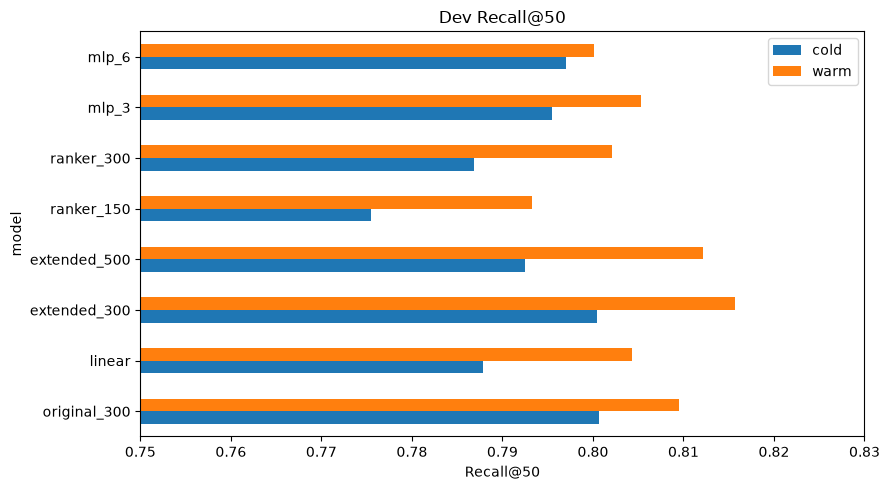

In [2]:
import matplotlib.pyplot as plt

mo_summary = pd.read_csv(mo_out / 'validation/model_family_experiments.csv')
mo_summary.set_index('model')[['cold', 'warm']].plot.barh(
    figsize=(9, 5), xlim=(0.75, 0.83), title='Dev Recall@50'
)
plt.xlabel('Recall@50')
plt.tight_layout()
plt.savefig(mo_out / 'figures/model_families.png', dpi=150)
plt.show()
